In [283]:
import numpy as np
import pandas as pd

In [284]:
df=pd.read_csv('startup_funding.csv')
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [285]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [286]:
df.drop(columns=['Remarks'],inplace=True)

In [287]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [288]:
df.set_index('Sr No',inplace=True)

In [289]:
df.head()

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [290]:
df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup',
    'Industry Vertical':'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investors',
    'InvestmentnType':'round',
    'Amount in USD':'amount'    
    
},inplace=True)

In [291]:
df.head()   

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [292]:
df['amount']=df['amount'].fillna('0')

In [293]:
df['amount'] = df['amount'].str.replace(',','')
df['amount'] = df['amount'].str.replace('undisclosed','0')
df['amount'] = df['amount'].str.replace('unknown','0')
df['amount'] = df['amount'].str.replace('Undisclosed','0')

In [294]:
df = df[df['amount'].str.isdigit()]

In [295]:
df['amount']=df['amount'].astype('float')

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3029 non-null   object 
 1   startup      3029 non-null   object 
 2   vertical     2858 non-null   object 
 3   subvertical  2104 non-null   object 
 4   city         2849 non-null   object 
 5   investors    3005 non-null   object 
 6   round        3027 non-null   object 
 7   amount       3029 non-null   float64
dtypes: float64(1), object(7)
memory usage: 213.0+ KB


In [297]:



def to_inr(dollar):
    inr = dollar * 82.5
    return inr/10000000


In [298]:
df['amount']=df['amount'].apply(to_inr)

In [299]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3029 non-null   object 
 1   startup      3029 non-null   object 
 2   vertical     2858 non-null   object 
 3   subvertical  2104 non-null   object 
 4   city         2849 non-null   object 
 5   investors    3005 non-null   object 
 6   round        3027 non-null   object 
 7   amount       3029 non-null   float64
dtypes: float64(1), object(7)
memory usage: 213.0+ KB


In [301]:
mask = df['date'] == '05/072018'

affected_rows = mask.sum()
print("Number of affected rows:", affected_rows)


Number of affected rows: 1


In [302]:
df['date'] = df['date'].str.replace('05/072018','05/07/2018')


In [303]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000


In [305]:
df['date'] = df['date'].str.replace(r'(\d{2}/\d{2})\.(\d{4})',
                                    r'\1/\2',
                                    regex=True)

In [307]:
df['date'] = df['date'].str.replace(r'/+', '/', regex=True)

In [308]:
temp=df['date'].copy()
converted_date = pd.to_datetime(temp,errors='coerce',dayfirst=True)
temp[temp.notna() & converted_date.isna()]

Sr No
2572    01/07/015
Name: date, dtype: object

In [309]:
df['date'] = pd.to_datetime(df['date'],errors='coerce',dayfirst=True)


In [310]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000


In [311]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         3028 non-null   datetime64[ns]
 1   startup      3029 non-null   object        
 2   vertical     2858 non-null   object        
 3   subvertical  2104 non-null   object        
 4   city         2849 non-null   object        
 5   investors    3005 non-null   object        
 6   round        3027 non-null   object        
 7   amount       3029 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 213.0+ KB


In [312]:
df = df.dropna(subset=['date','startup','vertical','city','investors','round','amount'])


In [313]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2822 non-null   datetime64[ns]
 1   startup      2822 non-null   object        
 2   vertical     2822 non-null   object        
 3   subvertical  2078 non-null   object        
 4   city         2822 non-null   object        
 5   investors    2822 non-null   object        
 6   round        2822 non-null   object        
 7   amount       2822 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 198.4+ KB


In [314]:
df.to_csv('Cleaned_startup_funding.csv',index=False)

In [315]:
df['investors'].hasnans

False

In [316]:
len(sorted(set(df['investors'].str.split(',').sum())))



3460

In [327]:
sorted(df['investors'].dropna().str.split(',').explode().str.strip().unique())

['',
 '"Kedaraa Capital',
 '& Others',
 '021 Capita',
 '100 Co-founders Lab and others.',
 '122 West Ventures',
 '1Crowd',
 '1Crowd (through crowd funding)',
 '1Crowd (through crowdfunding)',
 '3 undisclosed HNIs',
 '3 undisclosed investors',
 '3ONE4 Capital Advisors',
 '3One4 Capital',
 '3one4 Capital',
 '3one4 Capital Advisors LLP',
 '3one4 capital',
 '500 Start-Ups',
 '500 Startups',
 '500 Startups & Other HNIs',
 '50K Ventures',
 '50K Ventures & others',
 '50k Ventures',
 '91SpringBoard',
 '91maker.com',
 '91springboard',
 'A M Sikander',
 'A91 Partners',
 'AB Kinnevik',
 'ABB Technology Ventures',
 'ABCOM Investments',
 'ABI-Showatech (India) Ltd',
 'ABM Knowledgeware',
 'ADAG Reliance Private Equity',
 'AECAL',
 'AET Fund',
 'AJ Ventures and Jain International Trade Organisation (JITO)',
 'AL Nour International Holdings and Mark V Investments',
 'ANI Technologies Pvt. Ltd',
 'APIS Partners',
 'ASK Pravi',
 'ASP Consulting',
 'AV Thomas Group',
 'AVG Group',
 'AVN Business Solutio

In [328]:
df[df['investors'].str.contains(' IDG Ventures')].head(50)


,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
102,2019-04-13,Tripoto,Social Media,Travel,New Delhi,"Orchid India, Hornbill Orchid India Fund, Chir...",Series B,29.628844
259,2018-05-02,Bizongo,Consumer Internet,Aggregator For Packaging Material,Mumbai,"B Capital, International Finance Corporation (...",Private Equity,181.500000
310,2018-04-26,POPxo,Technology,Women Focussed Digital Media Platform,Delhi,"Neoplux, OPPO, IDG Ventures India, Kalaari Cap...",Private Equity,45.375000
505,2017-11-21,Heckyl,Technology,Big Data Analytics Platform,Mumbai,"Notion Capital, IDG Ventures",Private Equity,22.275000
528,2017-10-05,Little Black Book,Consumer Internet,Local Recommendations and Discoveries Platform,New Delhi,"Blume Ventures, IDG Ventures & Indian Angel Ne...",Private Equity,8.250000
673,2017-08-29,CureFit,Consumer Internet,End to End health and wellness platform.,Bangalore,"Accel Partners, IDG Ventures, Kalaari Capital,...",Private Equity,206.250000
964,2017-03-16,POPxo,Consumer Internet,Digital Media publication for women,New Delhi,"GREE Ventures, Kalaari Capital and IDG Venture...",Private Equity,25.575000
1012,2017-02-13,Sigtuple,Technology,Medical Automation platform,Bangalore,"Accel Partners, IDG Ventures, Endiya Partners,...",Private Equity,47.850000
1211,2016-11-14,Active.ai,Technology,Banking & Fintech Platform,Singapore,"Kalaari Capital, IDG Ventures India",Private Equity,24.750000


In [342]:
mask = df['investors'].str.contains(
    ' IDG Ventures',
    regex=False,
    na=False
)

vertical_counts = (
    df.loc[mask, 'vertical']
      .value_counts()
)
vertical_counts

vertical
Consumer Internet                  7
Technology                         6
eCommerce                          2
Social Media                       1
ECommerce                          1
global community for travellers    1
CRM / Analytics platform           1
Name: count, dtype: int64

In [ ]:
df[df['investors'].str.contains(' IDG Ventures',regex=False,na=False)].groupby('startup')['investors'].count().sort_values(ascending=False).head(5)

<Axes: ylabel='amount'>

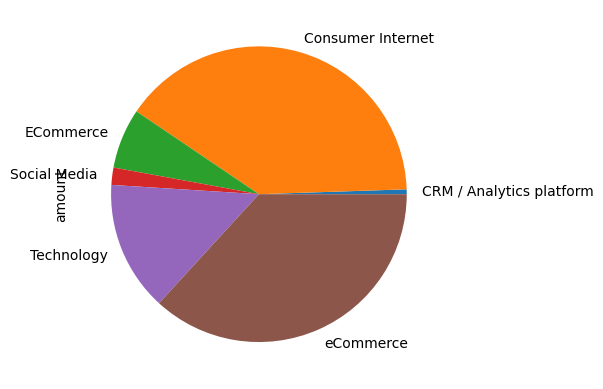

In [343]:
df[df['investors'].str.contains(' IDG Ventures',regex=False,na=False)].groupby('vertical')['amount'].sum().plot(kind='pie')